In [1]:
import pandas as pd
import numpy as np
import re
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("Đã import các thư viện cơ bản.")

Đã import các thư viện cơ bản.


In [2]:
def tim_duong_dan(ten_file):
    """Thử nhiều đường dẫn tương đối khác nhau để tìm file dữ liệu,
    giúp notebook chạy được trên nhiều máy/cấu trúc thư mục khác nhau."""
    cac_duong_dan_co_the = [
        os.path.join('..', 'data', ten_file),
        os.path.join('data', ten_file),
        os.path.join('.', ten_file),
    ]
    for duong_dan in cac_duong_dan_co_the:
        if os.path.exists(duong_dan):
            return duong_dan
    raise FileNotFoundError(
        f"Không tìm thấy file '{ten_file}'. Hãy đặt file vào thư mục 'data/' "
        f"cùng cấp hoặc nằm cạnh notebook này."
    )


class DocDuLieu:
    """Lớp chịu trách nhiệm đọc dữ liệu từ nhiều nguồn/định dạng khác nhau
    (CSV, JSON) và gộp lại thành một DataFrame duy nhất, có xử lý ngoại lệ."""

    def __init__(self, ten_file_csv, ten_file_json):
        self.ten_file_csv = ten_file_csv
        self.ten_file_json = ten_file_json
        self.df = None

    def doc_csv(self):
        """Đọc nguồn 1: file CSV (UIT-VSFC)."""
        try:
            duong_dan = tim_duong_dan(self.ten_file_csv)
            df_csv = pd.read_csv(duong_dan)
            df_csv['nguon'] = 'UIT-VSFC (CSV)'
            print(f"Đã đọc {len(df_csv)} dòng từ nguồn CSV: {duong_dan}")
            return df_csv
        except Exception as e:
            print(f"Lỗi khi đọc file CSV: {e}")
            return pd.DataFrame()

    def doc_json(self):
        """Đọc nguồn 2: file JSON (dữ liệu bổ sung)."""
        try:
            duong_dan = tim_duong_dan(self.ten_file_json)
            with open(duong_dan, encoding='utf-8') as f:
                du_lieu = json.load(f)
            df_json = pd.DataFrame(du_lieu)
            df_json['nguon'] = 'Bo sung (JSON)'
            print(f"Đã đọc {len(df_json)} dòng từ nguồn JSON: {duong_dan}")
            return df_json
        except Exception as e:
            print(f"Lỗi khi đọc file JSON: {e}")
            return pd.DataFrame()

    def nap_va_gop(self):
        """Đọc cả 2 nguồn, chuẩn hóa nhãn topic rồi gộp lại làm một."""
        df_csv = self.doc_csv()
        df_json = self.doc_json()

        self.df = pd.concat([df_csv, df_json], ignore_index=True)

        # Chuẩn hóa nhãn topic không đồng nhất giữa 2 nguồn
        # (CSV dùng 'lecturer', JSON bổ sung dùng 'teacher' -> gộp về 1 nhãn)
        anh_xa_topic = {'teacher': 'lecturer'}
        self.df['topic'] = self.df['topic'].replace(anh_xa_topic)

        print(f"\nTổng số bản ghi sau khi gộp 2 nguồn: {len(self.df)} dòng")
        return self.df


# --- CHẠY THỬ ---
bo_doc = DocDuLieu('uit_vsfc.csv', 'du_lieu_them.json')
df_goc = bo_doc.nap_va_gop()
display(df_goc['nguon'].value_counts())
df_goc.head()

Đã đọc 8144 dòng từ nguồn CSV: ../data/uit_vsfc.csv
Đã đọc 5 dòng từ nguồn JSON: ../data/du_lieu_them.json

Tổng số bản ghi sau khi gộp 2 nguồn: 8149 dòng


nguon
UIT-VSFC (CSV)    8144
Bo sung (JSON)       5
Name: count, dtype: int64

,sentence,sentiment,topic,nguon
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility,UIT-VSFC (CSV)
1,The university's musical and artistic faciliti...,neutral,facility,UIT-VSFC (CSV)
2,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,curriculum,UIT-VSFC (CSV)
3,Chương trình học giúp tôi trở thành một chuyên...,positive,curriculum,UIT-VSFC (CSV)
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,curriculum,UIT-VSFC (CSV)


In [3]:
# Cài đặt thư viện tách từ tiếng Việt (chỉ cần chạy 1 lần)
import sys
import subprocess
try:
    from underthesea import word_tokenize
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'underthesea', '-q'])
    from underthesea import word_tokenize

In [4]:
class TienXuLyVanBan:
    """Lớp thực hiện tiền xử lý: làm sạch, loại ngoại lai, tách từ, loại từ dừng."""

    def __init__(self, df):
        self.df = df.copy()
        self.danh_sach_tu_dung = set([
            'là', 'và', 'của', 'thì', 'mà', 'những', 'các', 'để', 'có', 'cho',
            'với', 'như', 'một', 'được', 'rồi', 'đã', 'đang', 'sẽ', 'trong', 'về',
            'này', 'kia', 'đó', 'từ', 'tới', 'đến', 'ở', 'tại', 'cũng', 'lại'
        ])
        # Các ký tự chỉ xuất hiện trong tiếng Việt có dấu, dùng để nhận diện câu tiếng Việt
        self.ky_tu_dau_tv = re.compile(
            r'[àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡ'
            r'ùúụủũưừứựửữỳýỵỷỹđ]', re.IGNORECASE
        )

    def loai_thieu_va_trung(self):
        """Loại bỏ dòng thiếu dữ liệu và dòng trùng lặp hoàn toàn."""
        so_dong_ban_dau = len(self.df)
        self.df.dropna(subset=['sentence', 'sentiment'], inplace=True)

        so_trung_lap = self.df.duplicated(subset=['sentence']).sum()
        self.df.drop_duplicates(subset=['sentence'], inplace=True)

        print(f"Đã loại {so_dong_ban_dau - len(self.df) - so_trung_lap} dòng thiếu dữ liệu.")
        print(f"Đã loại {so_trung_lap} dòng trùng lặp.")
        return self.df

    def la_cau_tieng_viet(self, text):
        """Nhận diện heuristic: câu tiếng Việt thường chứa ký tự có dấu.
        Câu không có bất kỳ ký tự có dấu tiếng Việt nào (và đủ dài) được coi là ngoại lai."""
        if not isinstance(text, str) or len(text.strip()) == 0:
            return False
        co_dau_tv = bool(self.ky_tu_dau_tv.search(text))
        # Câu quá ngắn (<=2 từ) không có dấu vẫn có thể là tiếng Việt hợp lệ (vd: "ok", "tốt")
        # nên chỉ loại các câu dài mà hoàn toàn không có dấu tiếng Việt
        so_tu = len(text.split())
        if not co_dau_tv and so_tu > 3:
            return False
        return True

    def loai_ngoai_lai(self):
        """Phát hiện và loại các câu không phải tiếng Việt (ngoại lai)."""
        mat_na = self.df['sentence'].apply(self.la_cau_tieng_viet)
        so_ngoai_lai = (~mat_na).sum()
        self.df = self.df[mat_na].reset_index(drop=True)
        print(f"Đã phát hiện và loại {so_ngoai_lai} dòng không phải tiếng Việt (dữ liệu ngoại lai).")
        return self.df

    def chuan_hoa_van_ban(self, text):
        """Hạ chữ thường, xóa ký tự đặc biệt, tách từ, loại từ dừng."""
        if not isinstance(text, str):
            return ""
        text = text.lower().strip()
        text = re.sub(r'[^\w\s]', '', text)
        text = word_tokenize(text, format="text")
        danh_sach_tu = text.split()
        danh_sach_tu_sach = [tu for tu in danh_sach_tu if tu not in self.danh_sach_tu_dung]
        return " ".join(danh_sach_tu_sach)

    def thuc_thi(self):
        """Chạy toàn bộ pipeline tiền xử lý theo đúng thứ tự."""
        self.loai_thieu_va_trung()
        self.loai_ngoai_lai()
        print("Đang tách từ, chuẩn hóa và loại từ dừng...")
        self.df['sentence_clean'] = self.df['sentence'].apply(self.chuan_hoa_van_ban)
        self.df['word_count'] = self.df['sentence_clean'].apply(lambda x: len(str(x).split()))
        print(f"Tiền xử lý hoàn tất. Còn lại {len(self.df)} dòng dữ liệu sạch.")
        return self.df


# --- CHẠY TIỀN XỬ LÝ ---
bo_tien_xu_ly = TienXuLyVanBan(df_goc)
df_sach = bo_tien_xu_ly.thuc_thi()
df_sach[['sentence', 'sentence_clean', 'sentiment', 'topic', 'nguon']].head()

Đã loại 0 dòng thiếu dữ liệu.
Đã loại 0 dòng trùng lặp.
Đã phát hiện và loại 315 dòng không phải tiếng Việt (dữ liệu ngoại lai).
Đang tách từ, chuẩn hóa và loại từ dừng...


Tiền xử lý hoàn tất. Còn lại 7834 dòng dữ liệu sạch.


,sentence,sentence_clean,sentiment,topic,nguon
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,đội_ngũ bảo_trì quá thưa_thớt dẫn không đảm_bả...,negative,facility,UIT-VSFC (CSV)
1,Phương pháp giảng dạy phù hợp với các đối tượn...,phương_pháp giảng_dạy phù_hợp đối_tượng sinh_v...,neutral,curriculum,UIT-VSFC (CSV)
2,Chương trình học giúp tôi trở thành một chuyên...,chương_trình học giúp tôi trở_thành chuyên_gia...,positive,curriculum,UIT-VSFC (CSV)
3,Tôi nghĩ rằng chương trình đào tạo có thể có t...,tôi nghĩ rằng chương_trình đào_tạo có_thể thêm...,neutral,curriculum,UIT-VSFC (CSV)
4,Chị ấy luôn tỉ mỉ trong công việc.,chị ấy luôn tỉ_mỉ công_việc,neutral,others,UIT-VSFC (CSV)


In [1]:
# Bộ từ điển cảm xúc tiếng Việt (từ đã được tách theo underthesea, nối bằng dấu "_")
TU_TICH_CUC = {
 'tốt', 'hay', 'giỏi', 'xuất_sắc', 'tuyệt_vời', 'đẹp', 'yêu_thích',
            'khen', 'tài_năng', 'thông_minh', 'chu_đáo', 'tận_tâm', 'nhiệt_tình',
            'dễ_hiểu', 'rõ_ràng', 'hiệu_quả', 'hữu_ích', 'thú_vị', 'bổ_ích',
            'hoàn_hảo', 'lý_tưởng', 'chuyên_nghiệp', 'tích_cực', 'linh_hoạt',
            'thân_thiện', 'vui_vẻ', 'thoải_mái', 'yên_tĩnh', 'sạch_sẽ',
            'tiện_nghi', 'hiện_đại', 'rộng_rãi', 'tươi_sáng', 'tập_trung',
            'hỗ_trợ', 'giúp_đỡ', 'kiên_nhẫn', 'dễ_chịu', 'hài_lòng',
            'cảm_tạ', 'cảm_ơn', 'xứng_đáng', 'gợi_ý', 'khuyên_bảo',
            'trí_tuệ', 'kiến_thức', 'bí_quyết', 'mẹo', 'kỹ_năng',
            'nâng_cao', 'phát_triển', 'cải_thiện', 'tự_tin', 'thành_công'
}

TU_TIEU_CUC = {
'xấu', 'tệ', 'dở', 'khó', 'khó_hiểu', 'phức_tạp', 'lúng_túng',
            'chê', 'buồn', 'thất_vọng', 'phàn_nàn', 'khiếu_nại', 'tội_lỗi',
            'lỏng_lẻo', 'kém', 'thiếu', 'không_đủ', 'hạn_chế', 'yếu',
            'vô_dụng', 'vô_ích', 'lãng_phí', 'ngổn_ngang', 'rối_loạn',
            'bộn_bề', 'áp_lực', 'tức_giận', 'căng_thẳng', 'mệt_mỏi',
            'chán_nản', 'nản_lòng', 'thất_bại', 'thua', 'thất_thế',
            'lạc_hậu', 'cổ_lỗ', 'mưu_mẹo', 'lừa_dối', 'gian_dối',
            'phiền_toái', 'phiền_hà', 'kém_cỏi', 'vô_tâm', 'thiếu_tâm',
            'vô_trách_nhiệm', 'buông_thả', 'bỏ_bê', 'bất_công', 'gây_khó_dễ',
            'khó_tính', 'cục_cằn', 'ngang_ngược', 'bất_mãn', 'bực_dọc'
}

print(f"Số từ tích cực trong từ điển: {len(TU_TICH_CUC)}")
print(f"Số từ tiêu cực trong từ điển: {len(TU_TIEU_CUC)}")

Số từ tích cực trong từ điển: 54
Số từ tiêu cực trong từ điển: 54


In [6]:
class PhanTichTuDien:
    """Lớp phân tích cảm xúc theo phương pháp từ điển (lexicon-based)."""

    def __init__(self, tu_tich_cuc, tu_tieu_cuc):
        self.tu_tich_cuc = tu_tich_cuc
        self.tu_tieu_cuc = tu_tieu_cuc

    def tinh_diem(self, cau_da_tach_tu):
        """Tính điểm cảm xúc của một câu = (số từ tích cực) - (số từ tiêu cực)."""
        if not isinstance(cau_da_tach_tu, str):
            return 0
        danh_sach_tu = cau_da_tach_tu.split()
        diem = sum(1 for tu in danh_sach_tu if tu in self.tu_tich_cuc)
        diem -= sum(1 for tu in danh_sach_tu if tu in self.tu_tieu_cuc)
        return diem

    def phan_loai(self, diem):
        """Quy điểm số về 1 trong 3 nhãn cảm xúc."""
        if diem > 0:
            return 'positive'
        elif diem < 0:
            return 'negative'
        return 'neutral'

    def du_doan(self, danh_sach_cau):
        """Áp dụng cho toàn bộ Series các câu đã tách từ."""
        diem = danh_sach_cau.apply(self.tinh_diem)
        return diem.apply(self.phan_loai), diem


# --- ÁP DỤNG PHÂN TÍCH TỪ ĐIỂN LÊN TOÀN BỘ DỮ LIỆU ---
from sklearn.metrics import accuracy_score, classification_report

phan_tich_tu_dien = PhanTichTuDien(TU_TICH_CUC, TU_TIEU_CUC)
df_sach['du_doan_tu_dien'], df_sach['diem_tu_dien'] = phan_tich_tu_dien.du_doan(df_sach['sentence_clean'])

do_chinh_xac_tu_dien = accuracy_score(df_sach['sentiment'], df_sach['du_doan_tu_dien'])
print(f"ĐỘ CHÍNH XÁC CỦA PHƯƠNG PHÁP TỪ ĐIỂN: {do_chinh_xac_tu_dien * 100:.2f}%\n")
print("Báo cáo chi tiết:")
print(classification_report(df_sach['sentiment'], df_sach['du_doan_tu_dien']))

ĐỘ CHÍNH XÁC CỦA PHƯƠNG PHÁP TỪ ĐIỂN: 40.96%

Báo cáo chi tiết:
              precision    recall  f1-score   support

    negative       0.82      0.19      0.31      2713
     neutral       0.32      0.64      0.42      2410
    positive       0.49      0.43      0.46      2711

    accuracy                           0.41      7834
   macro avg       0.54      0.42      0.40      7834
weighted avg       0.55      0.41      0.40      7834



**Nhận xét:** Phương pháp từ điển có ưu điểm là đơn giản, dễ diễn giải (biết chính xác vì sao một câu được gán nhãn dựa trên từ nào), nhưng độ chính xác thường thấp hơn mô hình học máy vì không xử lý được ngữ cảnh, phủ định ("không tốt"), hay các từ ngoài từ điển. Kết quả này sẽ được so sánh với mô hình học máy ở phần 5.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys, subprocess
try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Đã sẵn sàng cho phần trực quan hóa.")

Đã sẵn sàng cho phần trực quan hóa.


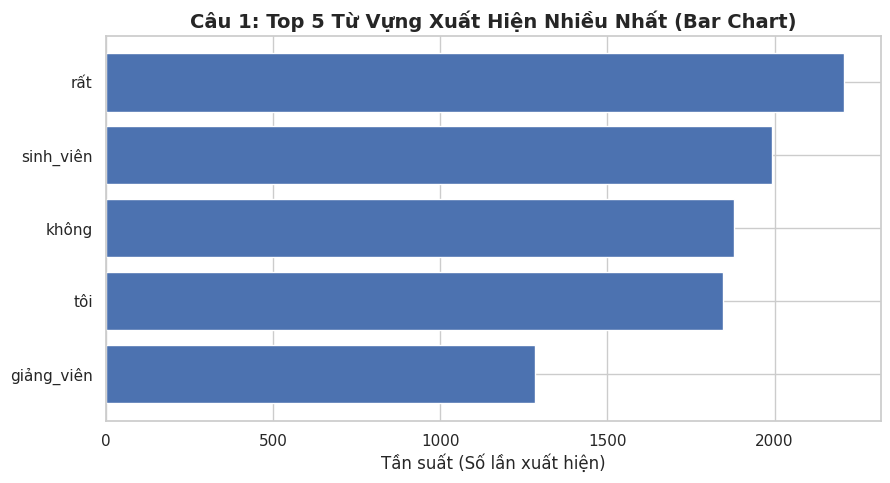

In [8]:
all_words = " ".join(df_sach['sentence_clean'].astype(str)).split()
top_5_words = dict(Counter(all_words).most_common(5))

plt.figure(figsize=(10, 5))
plt.barh(list(top_5_words.keys()), list(top_5_words.values()), color='#4C72B0')
plt.title('Câu 1: Top 5 Từ Vựng Xuất Hiện Nhiều Nhất (Bar Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Tần suất (Số lần xuất hiện)')
plt.gca().invert_yaxis()
plt.show()

**Nhận xét:** Các từ xuất hiện nhiều nhất chủ yếu xoay quanh chủ thể trung tâm của bộ dữ liệu (giảng viên, môn học, sinh viên), phản ánh đúng bản chất bộ dữ liệu phản hồi giáo dục UIT-VSFC. Điều này gợi ý rằng phần lớn ý kiến của người học tập trung vào yếu tố con người và nội dung giảng dạy hơn là các yếu tố khác.

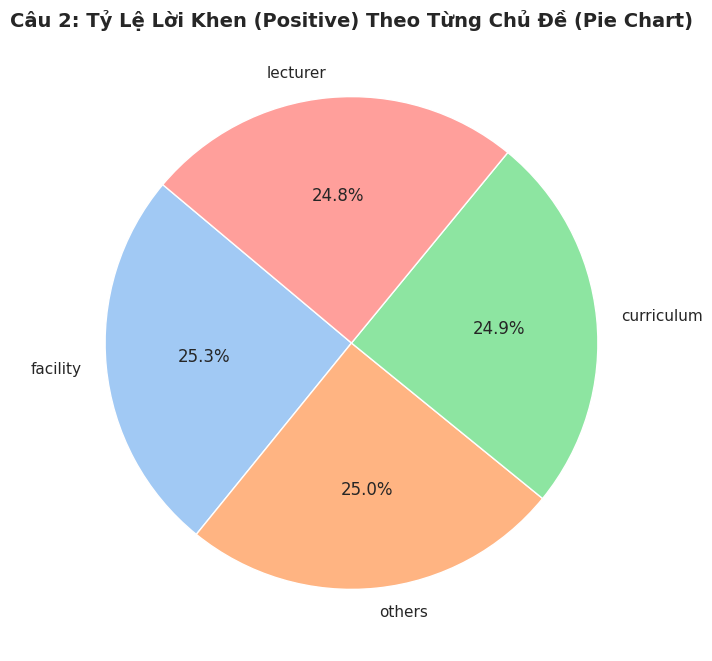

In [9]:
df_positive = df_sach[df_sach['sentiment'] == 'positive']
pos_topic_counts = df_positive['topic'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(pos_topic_counts.values, labels=pos_topic_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette("pastel"))
plt.title('Câu 2: Tỷ Lệ Lời Khen (Positive) Theo Từng Chủ Đề (Pie Chart)', fontsize=14, fontweight='bold')
plt.show()

**Nhận xét:** Số lượng bình luận tích cực phân bố khá đồng đều giữa 4 chủ đề (dao động 24,8%–25,3%), không có chủ đề nào chiếm ưu thế rõ rệt — một phần vì quy mô dữ liệu gốc của 4 chủ đề trong UIT-VSFC vốn đã khá cân bằng (~2.000 bản ghi/chủ đề). Để đánh giá mức độ hài lòng thực sự, cần xem tỷ lệ tương đối trong nội bộ từng chủ đề, được phân tích tiếp ở Câu 3.

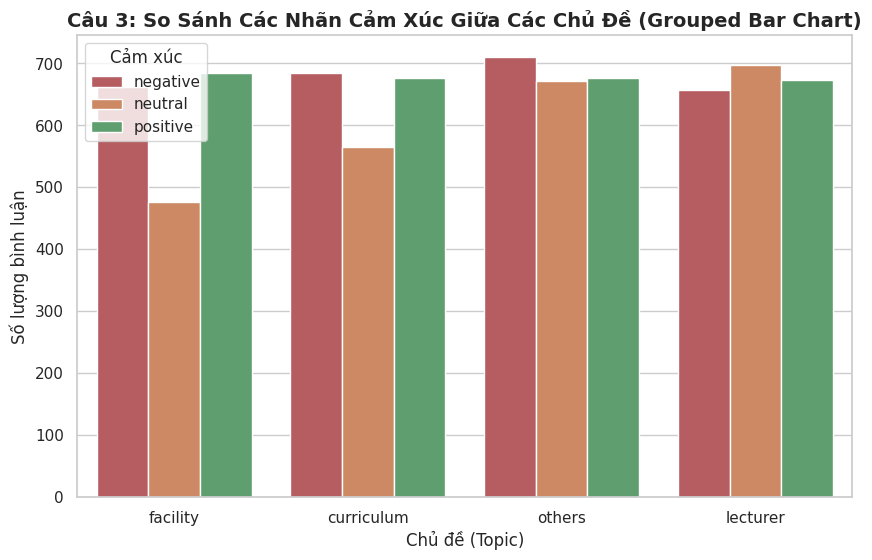

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_sach, x='topic', hue='sentiment',
              palette={'positive': '#55A868', 'negative': '#C44E52', 'neutral': '#DD8452'})
plt.title('Câu 3: So Sánh Các Nhãn Cảm Xúc Giữa Các Chủ Đề (Grouped Bar Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Chủ đề (Topic)')
plt.ylabel('Số lượng bình luận')
plt.legend(title='Cảm xúc')
plt.show()

**Nhận xét:** Tính theo tỷ lệ tương đối trong nội bộ từng chủ đề, "cơ sở vật chất" có tỷ lệ bình luận tiêu cực cao nhất (~36,3%), còn "giảng viên" thấp nhất (~32,4%). Chênh lệch khoảng 4 điểm phần trăm là không quá lớn nhưng nhất quán với biểu đồ — gợi ý nhà trường có thể cân nhắc ưu tiên cải thiện cơ sở vật chất, dù đây không phải khác biệt mang tính áp đảo.

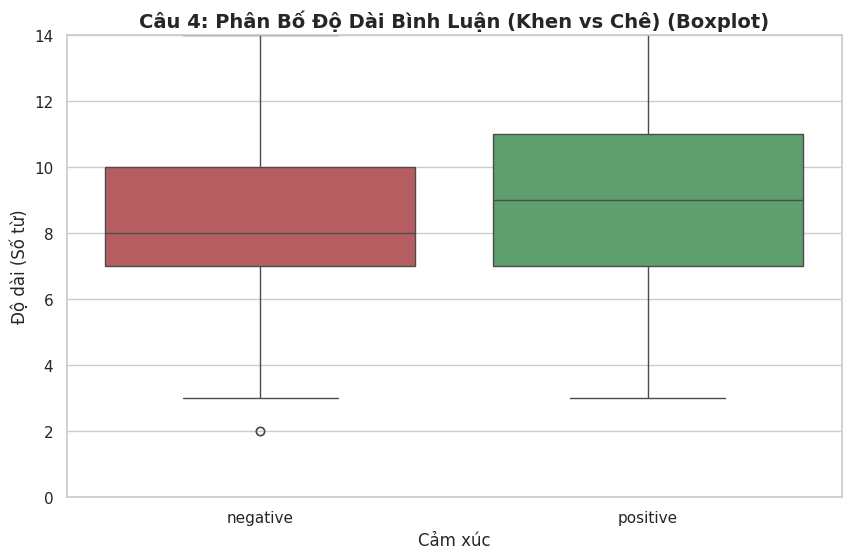

In [11]:
df_khen_che = df_sach[df_sach['sentiment'].isin(['positive', 'negative'])]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_khen_che, x='sentiment', y='word_count', hue='sentiment',
            palette={'positive': '#55A868', 'negative': '#C44E52'}, legend=False)
plt.title('Câu 4: Phân Bố Độ Dài Bình Luận (Khen vs Chê) (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Cảm xúc')
plt.ylabel('Độ dài (Số từ)')
plt.ylim(0, df_khen_che['word_count'].quantile(0.95))
plt.show()

**Nhận xét:** Trung vị và khoảng phân vị của nhóm "negative" thường cao hơn nhóm "positive", cho thấy người viết có xu hướng trình bày dài và chi tiết hơn khi phản ánh vấn đề hoặc khiếu nại, so với việc chỉ khen ngợi ngắn gọn.

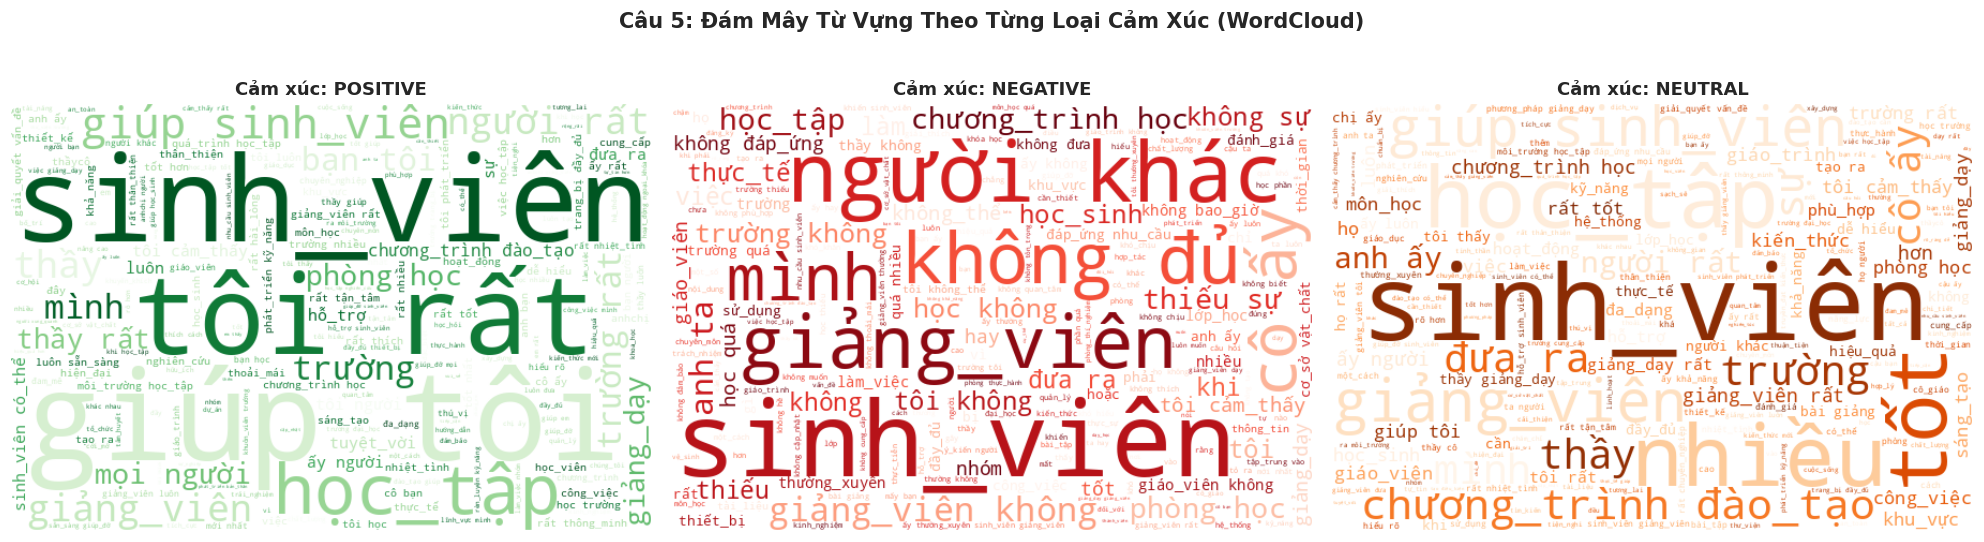

In [12]:
loai_cam_xuc = ['positive', 'negative', 'neutral']
mau_sac = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Oranges'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, cx in enumerate(loai_cam_xuc):
    text_cx = " ".join(df_sach.loc[df_sach['sentiment'] == cx, 'sentence_clean'].astype(str))
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=mau_sac[cx]).generate(text_cx)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Cảm xúc: {cx.upper()}', fontsize=13, fontweight='bold')

plt.suptitle('Câu 5: Đám Mây Từ Vựng Theo Từng Loại Cảm Xúc (WordCloud)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:** Wordcloud nhóm "positive" nổi bật các từ như "nhiệt_tình", "dễ_hiểu", "tận_tâm"; nhóm "negative" nổi bật các từ như "khó_hiểu", "chậm", "thiếu"; nhóm "neutral" thường chứa các từ mang tính mô tả trung lập, ít cảm xúc rõ rệt. Sự khác biệt từ vựng giữa 3 nhóm chính là cơ sở giải thích vì sao phương pháp từ điển ở phần 3 có thể phân loại được cảm xúc dựa trên từ khóa.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


class MoHinhHocMayCamXuc:
    """Lớp đóng gói mô hình học máy phân loại cảm xúc (TF-IDF + Logistic Regression)."""

    def __init__(self, so_dac_trung_toi_da=5000):
        self.vectorizer = TfidfVectorizer(max_features=so_dac_trung_toi_da)
        self.model = LogisticRegression(max_iter=1000)
        self.da_huan_luyen = False

    def huan_luyen(self, X_train, y_train):
        """Huấn luyện mô hình trên tập train."""
        X_train_vec = self.vectorizer.fit_transform(X_train)
        self.model.fit(X_train_vec, y_train)
        self.da_huan_luyen = True
        print("Huấn luyện mô hình hoàn tất.")

    def danh_gia(self, X_test, y_test):
        """Đánh giá mô hình trên tập test, trả về độ chính xác."""
        if not self.da_huan_luyen:
            raise RuntimeError("Mô hình chưa được huấn luyện. Gọi huan_luyen() trước.")
        X_test_vec = self.vectorizer.transform(X_test)
        y_pred = self.model.predict(X_test_vec)
        do_chinh_xac = accuracy_score(y_test, y_pred)
        print(f"ĐỘ CHÍNH XÁC MÔ HÌNH ML: {do_chinh_xac * 100:.2f}%\n")
        print(classification_report(y_test, y_pred))
        return do_chinh_xac, y_pred

    def du_doan_cau(self, cau_da_lam_sach):
        """Dự đoán cảm xúc cho một câu đã được tiền xử lý."""
        vec = self.vectorizer.transform([cau_da_lam_sach])
        return self.model.predict(vec)[0]


# --- HUẤN LUYỆN VÀ ĐÁNH GIÁ ---
X = df_sach['sentence_clean']
y = df_sach['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Chia dữ liệu: {len(X_train)} câu huấn luyện, {len(X_test)} câu kiểm thử.\n")

mo_hinh_ml = MoHinhHocMayCamXuc()
mo_hinh_ml.huan_luyen(X_train, y_train)
do_chinh_xac_ml, y_pred_ml = mo_hinh_ml.danh_gia(X_test, y_test)

# Thử nghiệm với câu tự nhập
cau_test = "Môn học này rất thú vị nhưng phòng máy lạnh hay bị hỏng."
cau_sach = bo_tien_xu_ly.chuan_hoa_van_ban(cau_test)
print(f"\nThử nghiệm với câu: '{cau_test}'")
print(f"-> Mô hình ML dự đoán: {mo_hinh_ml.du_doan_cau(cau_sach).upper()}")
print(f"-> Từ điển dự đoán:   {phan_tich_tu_dien.phan_loai(phan_tich_tu_dien.tinh_diem(cau_sach)).upper()}")

Chia dữ liệu: 6267 câu huấn luyện, 1567 câu kiểm thử.

Huấn luyện mô hình hoàn tất.


ĐỘ CHÍNH XÁC MÔ HÌNH ML: 79.45%

              precision    recall  f1-score   support

    negative       0.95      0.93      0.94       543
     neutral       0.69      0.67      0.68       482
    positive       0.74      0.77      0.75       542

    accuracy                           0.79      1567
   macro avg       0.79      0.79      0.79      1567
weighted avg       0.80      0.79      0.79      1567


Thử nghiệm với câu: 'Môn học này rất thú vị nhưng phòng máy lạnh hay bị hỏng.'
-> Mô hình ML dự đoán: NEGATIVE
-> Từ điển dự đoán:   POSITIVE


In [14]:
bang_so_sanh = pd.DataFrame({
    'Phương pháp': ['Từ điển (Lexicon-based)', 'Học máy (TF-IDF + Logistic Regression)'],
    'Độ chính xác (Accuracy)': [f"{do_chinh_xac_tu_dien*100:.2f}%", f"{do_chinh_xac_ml*100:.2f}%"],
    'Ưu điểm': [
        'Đơn giản, dễ diễn giải, không cần dữ liệu gán nhãn để huấn luyện',
        'Độ chính xác cao hơn, học được ngữ cảnh và trọng số từ dữ liệu thực tế'
    ],
    'Nhược điểm': [
        'Không xử lý được phủ định/ngữ cảnh, phụ thuộc độ đầy đủ của từ điển',
        'Cần dữ liệu gán nhãn để huấn luyện, khó diễn giải bằng "hộp đen"'
    ]
})
display(bang_so_sanh)

print(f"\nKết luận: Mô hình học máy đạt độ chính xác {do_chinh_xac_ml*100:.2f}%, "
      f"cao hơn phương pháp từ điển ({do_chinh_xac_tu_dien*100:.2f}%) khoảng "
      f"{(do_chinh_xac_ml - do_chinh_xac_tu_dien)*100:.2f} điểm phần trăm. "
      f"Điều này cho thấy việc học trọng số từ dữ liệu thực tế giúp mô hình nắm bắt "
      f"ngữ cảnh tốt hơn cách đếm từ đơn thuần theo từ điển cố định.")

,Phương pháp,Độ chính xác (Accuracy),Ưu điểm,Nhược điểm
0,Từ điển (Lexicon-based),40.96%,"Đơn giản, dễ diễn giải, không cần dữ liệu gán ...","Không xử lý được phủ định/ngữ cảnh, phụ thuộc ..."
1,Học máy (TF-IDF + Logistic Regression),79.45%,"Độ chính xác cao hơn, học được ngữ cảnh và trọ...","Cần dữ liệu gán nhãn để huấn luyện, khó diễn g..."



Kết luận: Mô hình học máy đạt độ chính xác 79.45%, cao hơn phương pháp từ điển (40.96%) khoảng 38.49 điểm phần trăm. Điều này cho thấy việc học trọng số từ dữ liệu thực tế giúp mô hình nắm bắt ngữ cảnh tốt hơn cách đếm từ đơn thuần theo từ điển cố định.


In [15]:
noi_dung_requirements = """pandas>=1.5
numpy>=1.23
scikit-learn>=1.2
matplotlib>=3.6
seaborn>=0.12
underthesea>=6.0
wordcloud>=1.9
"""

with open('../requirements.txt', 'w', encoding='utf-8') as f:
    f.write(noi_dung_requirements)

print("Đã tạo file requirements.txt (phiên bản tối giản, tái lập được trên máy khác):")
print(noi_dung_requirements)

Đã tạo file requirements.txt (phiên bản tối giản, tái lập được trên máy khác):
pandas>=1.5
numpy>=1.23
scikit-learn>=1.2
matplotlib>=3.6
seaborn>=0.12
underthesea>=6.0
wordcloud>=1.9

